A cleaner version

In [1]:
from huggingface_hub import login
import os
from dotenv import load_dotenv

# Load environment variables
load_dotenv('./env')

e:\1_Codes\Multimodal_Datasets_Generative_Reasoning\mm_data_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


False

In [ ]:
##


In [3]:
system_message = """You are a Vision Language Model specialized in interpreting visual data from chart images.
Your task is to analyze the provided chart image and respond to queries with concise answers, usually a single word, number, or short phrase.
The charts include a variety of types (e.g., line charts, bar charts) and contain colors, labels, and text.
Focus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary."""

In [4]:
def format_data(sample):
    return [
        {
            "role": "system",
            "content": [
                {
                    "type": "text",
                    "text": system_message
                }
            ],
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": sample["image"],
                },
                {
                    "type": "text",
                    "text": sample['query'],
                }
            ],
        },
        {
            "role": "assistant",
            "content": [
                {
                    "type": "text",
                    "text": sample["label"][0]
                }
            ],
        },
    ]

In [6]:
from datasets import load_dataset

dataset_id = "HuggingFaceM4/ChartQA"
train_dataset, eval_dataset, test_dataset = load_dataset(dataset_id, split=['train[:10%]', 'val[:10%]', 'test[:10%]'])

In [7]:
train_dataset

Dataset({
    features: ['image', 'query', 'label', 'human_or_machine'],
    num_rows: 2830
})

In [8]:
train_dataset = [format_data(sample) for sample in train_dataset]
eval_dataset = [format_data(sample) for sample in eval_dataset]
test_dataset = [format_data(sample) for sample in test_dataset]

In [9]:
train_dataset[200]

[{'role': 'system',
  'content': [{'type': 'text',
    'text': 'You are a Vision Language Model specialized in interpreting visual data from chart images.\nYour task is to analyze the provided chart image and respond to queries with concise answers, usually a single word, number, or short phrase.\nThe charts include a variety of types (e.g., line charts, bar charts) and contain colors, labels, and text.\nFocus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary.'}]},
 {'role': 'user',
  'content': [{'type': 'image',
    'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=308x369>},
   {'type': 'text',
    'text': 'Is the rightmost value of light brown graph 58?'}]},
 {'role': 'assistant', 'content': [{'type': 'text', 'text': 'No'}]}]

In [10]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
# processor = AutoProcessor.from_pretrained(model_id, use_fast=True, padding_side="left")


In [ ]:
import torch
from transformers import (
    Qwen2_5_VLForConditionalGeneration, 
    AutoTokenizer,
    AutoImageProcessor
)

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# Load model
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

# Load tokenizer and image processor separately
tokenizer = AutoTokenizer.from_pretrained(model_id)
image_processor = AutoImageProcessor.from_pretrained(model_id)

print("Model and components loaded successfully!")

# Create a simple processor-like object if needed
class SimpleProcessor:
    def __init__(self, tokenizer, image_processor):
        self.tokenizer = tokenizer
        self.image_processor = image_processor
    
    def __call__(self, text=None, images=None, **kwargs):
        result = {}
        if text is not None:
            result.update(self.tokenizer(text, **kwargs))
        if images is not None:
            result.update(self.image_processor(images, **kwargs))
        return result

processor = SimpleProcessor(tokenizer, image_processor)

In [11]:
train_dataset[0]

[{'role': 'system',
  'content': [{'type': 'text',
    'text': 'You are a Vision Language Model specialized in interpreting visual data from chart images.\nYour task is to analyze the provided chart image and respond to queries with concise answers, usually a single word, number, or short phrase.\nThe charts include a variety of types (e.g., line charts, bar charts) and contain colors, labels, and text.\nFocus on delivering accurate, succinct answers based on the visual information. Avoid additional explanation unless absolutely necessary.'}]},
 {'role': 'user',
  'content': [{'type': 'image',
    'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=422x359>},
   {'type': 'text', 'text': 'Is the value of Favorable 38 in 2015?'}]},
 {'role': 'assistant', 'content': [{'type': 'text', 'text': 'Yes'}]}]

In [12]:
train_dataset[0][1:2]

[{'role': 'user',
  'content': [{'type': 'image',
    'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=422x359>},
   {'type': 'text', 'text': 'Is the value of Favorable 38 in 2015?'}]}]

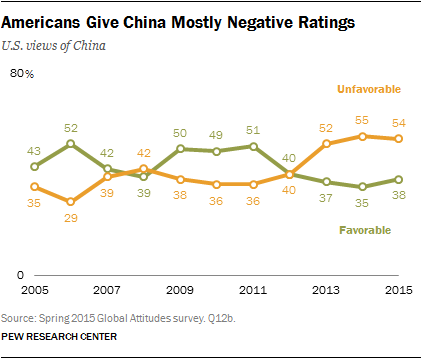

In [13]:
train_dataset[0][1]['content'][0]['image']

In [14]:
from qwen_vl_utils import process_vision_info

def generate_text_from_sample(model, processor, sample, max_new_tokens=1024, device="cuda"):
    # Prepare the text input by applying the chat template
    text_input = processor.apply_chat_template(
        sample[1:2],  # Use the sample without the system message
        tokenize=False,
        add_generation_prompt=True
    )

    # Process the visual input from the sample
    image_inputs, _ = process_vision_info(sample)

    # Prepare the inputs for the model
    model_inputs = processor(
        text=[text_input],
        images=image_inputs,
        return_tensors="pt",
    ).to(device)  # Move inputs to the specified device

    # Generate text with the model
    generated_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens)

    # Trim the generated ids to remove the input ids
    trimmed_generated_ids = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    # Decode the output text
    output_text = processor.batch_decode(
        trimmed_generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )

    return output_text[0]  # Return the first decoded output text

In [15]:
from qwen_vl_utils import process_vision_info

def generate_text_from_sample(model, processor, sample, max_new_tokens=1024, device="cpu"):
    text_input = processor.tokenizer.apply_chat_template(
        sample[1:2],
        tokenize=False,
        add_generation_prompt=True
    )
    
    image_inputs, _ = process_vision_info(sample)
    
    # Process text and images separately
    text_inputs = processor.tokenizer(
        [text_input],
        return_tensors="pt",
    )
    
    if image_inputs:
        image_features = processor.image_processor(
            images=image_inputs,
            return_tensors="pt",
        )
        model_inputs = {**text_inputs, **image_features}
    else:
        model_inputs = text_inputs
    
    model_inputs = {k: v.to(device) for k, v in model_inputs.items()}
    
    generated_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens)
    
    trimmed_generated_ids = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(model_inputs['input_ids'], generated_ids)
    ]
    
    output_text = processor.tokenizer.batch_decode(
        trimmed_generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )
    
    return output_text[0]

In [ ]:
import torch
from transformers import Qwen2_5_VLForConditionalGeneration
from transformers.models.auto import video_processing_auto

# More aggressive monkey patch
def fixed_video_processor_class_from_name(class_name: str):
    mapping = video_processing_auto.VIDEO_PROCESSOR_MAPPING_NAMES
    if mapping is None or not isinstance(mapping, dict):
        return None
    for module_name, extractors in mapping.items():
        if extractors is not None and class_name in extractors:
            from transformers.models.auto.configuration_auto import model_type_to_module_name
            import importlib
            module_name = model_type_to_module_name(module_name)
            module = importlib.import_module(f".{module_name}", "transformers.models")
            return getattr(module, class_name)
    return None

# Replace the broken function
video_processing_auto.video_processor_class_from_name = fixed_video_processor_class_from_name

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

from transformers import Qwen2VLProcessor
processor = Qwen2VLProcessor.from_pretrained(model_id)

print("Processor loaded successfully!")

In [ ]:
import torch
from transformers import AutoTokenizer, AutoImageProcessor, Qwen2_5_VLForConditionalGeneration
from qwen_vl_utils import process_vision_info

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
image_processor = AutoImageProcessor.from_pretrained(model_id)

def generate_text_from_sample(model, tokenizer, image_processor, sample, max_new_tokens=128):
    device = next(model.parameters()).device
    messages = sample[1:2]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, _ = process_vision_info(messages)
    
    inputs = tokenizer(text=[text], return_tensors="pt").to(device)
    
    if image_inputs:
        pixel_values = image_processor(images=image_inputs, return_tensors="pt")["pixel_values"].to(device)
        inputs["pixel_values"] = pixel_values
    
    output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    output_ids = output_ids[:, inputs["input_ids"].shape[1]:]
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

# Test
output = generate_text_from_sample(model, tokenizer, image_processor, train_dataset[1])
print(output)

In [ ]:
# Example of how to call the method with sample:
output = generate_text_from_sample(model, processor, train_dataset[1])
output

In [ ]:
from qwen_vl_utils import process_vision_info

def generate_text_from_sample(model, processor, sample, max_new_tokens=1024, device="cuda"):
    # Prepare the text input by applying the chat template
    # Use the tokenizer's apply_chat_template method
    text_input = processor.tokenizer.apply_chat_template(
        sample[1:2],  # Use the sample without the system message
        tokenize=False,
        add_generation_prompt=True
    )

    # Process the visual input from the sample
    image_inputs, _ = process_vision_info(sample)

    # Prepare the inputs for the model
    # Process text with tokenizer and images with image_processor
    text_inputs = processor.tokenizer(
        text=[text_input],
        return_tensors="pt",
    )
    
    if image_inputs:
        image_features = processor.image_processor(
            images=image_inputs,
            return_tensors="pt",
        )
        # Combine text and image inputs
        model_inputs = {**text_inputs, **image_features}
    else:
        model_inputs = text_inputs
    
    # Move inputs to the specified device
    model_inputs = {k: v.to(device) for k, v in model_inputs.items()}

    # Generate text with the model
    generated_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens)

    # Trim the generated ids to remove the input ids
    trimmed_generated_ids = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(model_inputs['input_ids'], generated_ids)
    ]

    # Decode the output text
    output_text = processor.tokenizer.batch_decode(
        trimmed_generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )

    return output_text[0]  # Return the first decoded output text


# Example of how to call the method with sample:
output = generate_text_from_sample(model, processor, train_dataset[1])
output

In [ ]:
from transformers import Qwen2VLProcessor

# Try loading with trust_remote_code
try:
    processor = Qwen2VLProcessor.from_pretrained(
        model_id,
        trust_remote_code=True
    )
    print("Processor loaded successfully!")
except Exception as e:
    print(f"Error: {e}")
    # Fall back to manual loading
    from transformers import AutoTokenizer, AutoImageProcessor
    
    tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
    image_processor = AutoImageProcessor.from_pretrained(model_id, trust_remote_code=True)
    
    class SimpleProcessor:
        def __init__(self, tokenizer, image_processor):
            self.tokenizer = tokenizer
            self.image_processor = image_processor
        
        def __call__(self, text=None, images=None, **kwargs):
            result = {}
            if text is not None:
                result.update(self.tokenizer(text, **kwargs))
            if images is not None:
                result.update(self.image_processor(images, **kwargs))
            return result
    
    processor = SimpleProcessor(tokenizer, image_processor)
    print("Using SimpleProcessor")

In [ ]:
import torch

# Auto-detect available device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# If the model was loaded with device_map="auto", it's already on the right device
# Just make sure inputs go to the same device as the model
model_device = next(model.parameters()).device
print(f"Model is on: {model_device}")

output = generate_text_from_sample(model, processor, train_dataset[1], device=model_device)
output

In [ ]:
from qwen_vl_utils import process_vision_info

def generate_text_from_sample(model, processor, sample, max_new_tokens=1024, device="cpu"):
    # Prepare the text input by applying the chat template
    text_input = processor.tokenizer.apply_chat_template(
        sample[1:2],  # Use the sample without the system message
        tokenize=False,
        add_generation_prompt=True
    )

    # Process the visual input from the sample
    image_inputs, _ = process_vision_info(sample)

    # Prepare the inputs for the model
    text_inputs = processor.tokenizer(
        text=[text_input],
        return_tensors="pt",
    )
    
    if image_inputs:
        image_features = processor.image_processor(
            images=image_inputs,
            return_tensors="pt",
        )
        model_inputs = {**text_inputs, **image_features}
    else:
        model_inputs = text_inputs
    
    # Move inputs to the specified device
    model_inputs = {k: v.to(device) for k, v in model_inputs.items()}

    # Generate text with the model
    generated_ids = model.generate(**model_inputs, max_new_tokens=max_new_tokens)

    # Trim the generated ids to remove the input ids
    trimmed_generated_ids = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(model_inputs['input_ids'], generated_ids)
    ]

    # Decode the output text
    output_text = processor.tokenizer.batch_decode(
        trimmed_generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )

    return output_text[0]

# Run the generation
output = generate_text_from_sample(model, processor, train_dataset[1], device="cpu")
print("Generated output:")
print(output)

#### Next

In [ ]:
import gc
import time

def clear_memory():
    # Delete variables if they exist in the current global scope
    if 'inputs' in globals(): del globals()['inputs']
    if 'model' in globals(): del globals()['model']
    if 'processor' in globals(): del globals()['processor']
    if 'trainer' in globals(): del globals()['trainer']
    if 'peft_model' in globals(): del globals()['peft_model']
    if 'bnb_config' in globals(): del globals()['bnb_config']
    time.sleep(2)

    # Garbage collection and clearing CUDA memory
    gc.collect()
    time.sleep(2)
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    time.sleep(2)
    gc.collect()
    time.sleep(2)

    print(f"GPU allocated memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"GPU reserved memory: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

clear_memory()